### Getting started with langgraph
Langgraph is a library for building stateful, multi-actor applications with LLMs, used to crate agent and multi-agent workflows.

Langgraph is inspired by Pregel and Apache Beam. The public inerface draws inspirations from Networksx. Langgraph is build by LanbChain Inc, the creators of Langchain, but can be used without Langchain. 
Langgraph powers production-grade agents, trunsted by Linked, Uber, Klarna, GitLab, and many more. LangGraph provided fine-grained control over both the flow and state of your agent applications. it implements a central persisntence layer, enabling features that are common to most agent archituctures:

- Memory : Langgraph persists arbitrary aspects of your applications's state, supporting memeory of conversations and other updates within and across user interactions;
- Human-in-the-loop: Because state is checkpointed, execution can be interrrupted and resumed, allowing for decisions, validation, and corrections at key stages via human input.


In [35]:
import os
from dotenv import load_dotenv

load_dotenv("/Users/biman_giri/Documents/OfficeWork/MyDay2DayLearning/.env")
openai_token = os.getenv("OPENAI_API_TOKEN")
openai_base_url = os.getenv("OPENAI_API_BASE")
lanchain_endpoint = os.getenv("LANGSMITH_ENDPOINT")
lanchain_api_key = os.getenv("LANGSMITH_API_KEY")
lanchain_project = os.getenv("LANGSMITH_PROJECT")
lanchain_tracing_v2 = os.getenv("LANGSMITH_TRACING")

#### Build a simple workflow or graph using LangGraph

##### State : first , define the state of the graph .The state schema serves as the input schema for all Nodes and Edges in the graph

In [3]:
from typing_extensions import TypedDict


class State(TypedDict):
    graph_info: str

#### Nodes : 
Nodes are just python functions. the first positional argument is the state, as defined above.
Because the state is a TypedDict with schema as defined above, each node can access the key, graph_state, with state['graph_state']. Each Node returns a new value of the state key graph_state. By default, the new value returned by each node will override the prior state value.

In [ ]:
def start_play(state: State):
    print("Start_play node has been called")
    return {"graph_info": state["graph_info"] + "I am planing to play a game"}


def badminton_game(state: State):
    print("Badminton game node has been called")
    return {"graph_info": state["graph_info"] + " badminton"}


def tennis_game(state: State):
    print("Tennis game node has been called")
    return {"graph_info": state["graph_info"] + " tennis"}


import random
from typing import Literal


def random_play(state: State) -> Literal["badminton_game", "tennis_game"]:
    graph_info = state["graph_info"]
    if random.random() > 0.5:
        return "badminton_game"
    else:
        return "tennis_game"

#### Graph Construction 
- Now, we build the graph from our components defined above.
- The StataGraph clas is the graph class that we can use.
- First, we initialize a StateGraph with the State class we defined above.
- Then we add our nodes and edges.
- We use the START Node, a special node that sends user input to the graph, to indicate where to start our graph.
- The End Node is a special node that represents a terminal node.
- Finally, we compile our graph to perform few basic checks on the graph structure. 
- we can visualize the graph as a Mermaid Diagram.



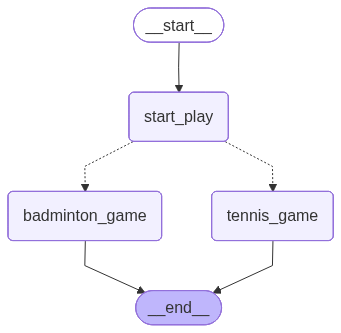

In [ ]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

## build the graph
graph = StateGraph(State)


### adding the nodes to the graph

graph.add_node("start_play", start_play)
graph.add_node("badminton_game", badminton_game)
graph.add_node("tennis_game", tennis_game)
#### schedule the flow of the graph

graph.add_edge(START, "start_play")
graph.add_conditional_edges("start_play", random_play)
graph.add_edge("badminton_game", END)
graph.add_edge("tennis_game", END)


### compile the graph
graph_builder = graph.compile()
### visualize the graph
display(Image(graph_builder.get_graph().draw_mermaid_png()))

#

In [10]:
graph_builder.get_graph().print_ascii()

                +-----------+                 
                | __start__ |                 
                +-----------+                 
                       *                      
                       *                      
                       *                      
                +------------+                
                | start_play |                
                +------------+                
               ..            ..               
             ..                ..             
           ..                    ..           
+----------------+           +-------------+  
| badminton_game |           | tennis_game |  
+----------------+           +-------------+  
               **            **               
                 **        **                 
                   **    **                   
                 +---------+                  
                 | __end__ |                  
                 +---------+                  


In [11]:
print(graph_builder.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	start_play(start_play)
	badminton_game(badminton_game)
	tennis_game(tennis_game)
	__end__([<p>__end__</p>]):::last
	__start__ --> start_play;
	start_play -.-> badminton_game;
	start_play -.-> tennis_game;
	badminton_game --> __end__;
	tennis_game --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [22]:
graph_builder.invoke({"graph_info": "Hello my name is Krish "})

Start_play node has been called
Badminton game node has been called


{'graph_info': 'Hello my name is Krish I am planing to play a game badminton'}

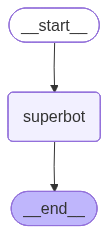

In [ ]:
from langchain_openai import ChatOpenAI

llm_model = ChatOpenAI(
    model="gpt-4o",
    temperature=0.0,
    api_key=openai_token,
    base_url=openai_base_url,
)

### reducers

from typing import Annotated
from langgraph.graph.message import add_messages


class State(TypedDict):
    messages: Annotated[list, add_messages]


### we will start creating nodes
def superbot(state: State):
    return {"messages": [llm_model.invoke(state["messages"])]}


graph = StateGraph(State)
graph.add_node("superbot", superbot)
graph.add_edge(START, "superbot")
graph.add_edge("superbot", END)


graph_builder = graph.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [ ]:
graph_builder.invoke({"messages": "Hi my name is krish, I like football"})

{'messages': [HumanMessage(content='Hi my name is krish, I like football', additional_kwargs={}, response_metadata={}, id='c33f6f68-8a9f-4098-a595-4360516c2a0c'),
  AIMessage(content="Hi Krish! It's great to meet you. Football is an exciting sport with a lot of action and strategy. Do you have a favorite team or player?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 17, 'total_tokens': 49, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_11da807510', 'id': 'chatcmpl-DLSzgsBBsyqrqsYckRAgphFXer7UR', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d0b28-b797-7a71-809c-ac6bdd630742-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'inp

In [ ]:
#### straming the response
for event in graph_builder.stream(
    {"messages": "Hi my name is krish, I like football"}, stream_mode="values"
):
    print(event)

{'messages': [HumanMessage(content='Hi my name is krish, I like football', additional_kwargs={}, response_metadata={}, id='4b3625d6-833e-4546-b0c0-ca367b3dfd76')]}
{'messages': [HumanMessage(content='Hi my name is krish, I like football', additional_kwargs={}, response_metadata={}, id='4b3625d6-833e-4546-b0c0-ca367b3dfd76'), AIMessage(content="Hi Krish! It's great to meet you. Football is an exciting sport with a lot of action and strategy. Do you have a favorite team or player?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 32, 'prompt_tokens': 17, 'total_tokens': 49, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_11da807510', 'id': 'chatcmpl-DLT2CjqO2vhNXVBk66si8kdXmp60z', 'service_tier': 'def

#### State Schema with TypedDict
- When we define a Langgraph stategraph, we use a state schema.
- The state schema represents the structure and types od data that our graph will use.
- A;ll nodes are expected to communicate with that schema.
- Langgraph offers flexibility in how you define your state schema, accommodating various python types and validation approaches.


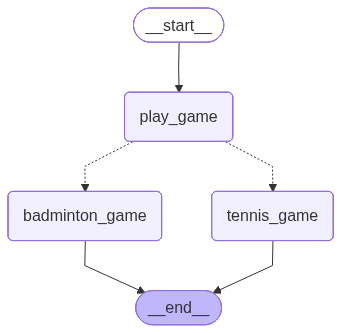

In [ ]:
from typing_extensions import TypedDict
from typing import Literal


class TypedDictState(TypedDict):
    name: Annotated[str, "name of the person"]
    game: Annotated[str, "game to play"]


def play_game(state: TypedDictState):
    print("----- play game node has been called -----")
    return {"name": state["name"], "game": "wantes to play "}


def badminton_game(state: TypedDictState):
    print("----- badminton game node has been called -----")
    return {"game": state["game"] + "badminton"}


def tennis_game(state: TypedDictState):
    print("----- tennis game node has been called -----")
    return {"game": state["game"] + "tennis"}


def random_play(state: TypedDictState) -> Literal["badminton_game", "tennis_game"]:
    if random.random() > 0.5:
        return "badminton_game"
    else:
        return "tennis_game"


builder_with_typeddict = StateGraph(TypedDictState)
builder_with_typeddict.add_node("play_game", play_game)
builder_with_typeddict.add_node("badminton_game", badminton_game)
builder_with_typeddict.add_node("tennis_game", tennis_game)

builder_with_typeddict.add_edge(START, "play_game")
builder_with_typeddict.add_conditional_edges("play_game", random_play)
builder_with_typeddict.add_edge("badminton_game", END)
builder_with_typeddict.add_edge("tennis_game", END)


builder_graph_with_typeddict = builder_with_typeddict.compile()
display(Image(builder_graph_with_typeddict.get_graph().draw_mermaid_png()))

In [60]:
builder_graph_with_typeddict.invoke({"name": "Biman"})

----- play game node has been called -----
----- tennis game node has been called -----


{'name': 'Biman', 'game': 'wantes to play tennis'}

#### State Schema with DataClass

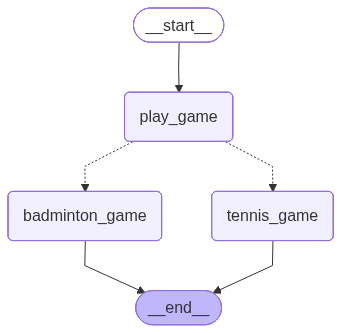

In [ ]:
from dataclasses import dataclass
from typing import Literal
from typing import Optional


@dataclass
class DataClassState:
    name: Annotated[str, "name of the person"]
    game: Optional[Annotated[str, "game to play"]] = None


def play_game(state: DataClassState):
    print("----- play game node has been called -----")
    return {"name": state.name, "game": "wantes to play "}


def badminton_game(state: DataClassState):
    print("----- badminton game node has been called -----")
    return {"game": state.game + "badminton"}


def tennis_game(state: DataClassState):
    print("----- tennis game node has been called -----")
    return {"game": state.game + "tennis"}


def random_play(state: DataClassState) -> Literal["badminton_game", "tennis_game"]:
    if random.random() > 0.5:
        return "badminton_game"
    else:
        return "tennis_game"


builder_with_dataclass = StateGraph(DataClassState)
builder_with_dataclass.add_node("play_game", play_game)
builder_with_dataclass.add_node("badminton_game", badminton_game)
builder_with_dataclass.add_node("tennis_game", tennis_game)

builder_with_dataclass.add_edge(START, "play_game")
builder_with_dataclass.add_conditional_edges("play_game", random_play)
builder_with_dataclass.add_edge("badminton_game", END)
builder_with_dataclass.add_edge("tennis_game", END)


builder_graph_with_dataclass = builder_with_dataclass.compile()
display(Image(builder_graph_with_dataclass.get_graph().draw_mermaid_png()))

In [61]:
builder_graph_with_dataclass.invoke(DataClassState(name="Biman"))

----- play game node has been called -----
----- tennis game node has been called -----


{'name': 'Biman', 'game': 'wantes to play tennis'}

#### Pydantic 

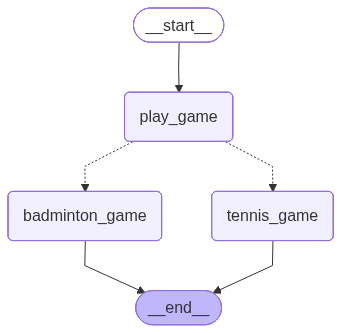

In [68]:
from pydantic import BaseModel, Field
from typing import Literal


class PydanticState(BaseModel):
    name: str = Field(description="name of the person")
    game: str = Field(description="game to play", default=None)


def play_game(state: PydanticState):
    print("----- play game node has been called -----")
    return {"name": state.name, "game": "wantes to play "}


def badminton_game(state: PydanticState):
    print("----- badminton game node has been called -----")
    return {"game": state.game + "badminton"}


def tennis_game(state: PydanticState):
    print("----- tennis game node has been called -----")
    return {"game": state.game + "tennis"}


def random_play(state: PydanticState) -> Literal["badminton_game", "tennis_game"]:
    if random.random() > 0.5:
        return "badminton_game"
    else:
        return "tennis_game"


builder_with_pydantic = StateGraph(PydanticState)
builder_with_pydantic.add_node("play_game", play_game)
builder_with_pydantic.add_node("badminton_game", badminton_game)
builder_with_pydantic.add_node("tennis_game", tennis_game)

builder_with_pydantic.add_edge(START, "play_game")
builder_with_pydantic.add_conditional_edges("play_game", random_play)
builder_with_pydantic.add_edge("badminton_game", END)
builder_with_pydantic.add_edge("tennis_game", END)


builder_graph_with_pydantic = builder_with_pydantic.compile()
display(Image(builder_graph_with_pydantic.get_graph().draw_mermaid_png()))

In [69]:
builder_graph_with_pydantic.invoke(PydanticState(name="Biman"))

----- play game node has been called -----
----- badminton game node has been called -----


{'name': 'Biman', 'game': 'wantes to play badminton'}

#### Chain Using LangGraph
In this section we will see how we can build a simple chain using LangGraph that uses 4 important concepts
- How to use chat messages as our graph state.
- How to use chat models in graph nodes.
- How to bind tools to our LLM in chat models.
- How to execute the tools call in our graph nodes.


In [ ]:
from langchain_core.messages import HumanMessage, AIMessage
from pprint import pprint

messages = [AIMessage(content="Please tell me how can I help you")]
messages.append(HumanMessage(content="I want to learn how to do programming"))
messages.append(AIMessage(content="Please tell me which language you want to learn"))
messages.append(HumanMessage(content="I want to learn python"))
for message in messages:
    message.pretty_print()

================================== Ai Message ==================================

Please tell me how can I help you
================================ Human Message =================================

I want to learn how to do programming
================================== Ai Message ==================================

Please tell me which language you want to learn
================================ Human Message =================================

I want to learn python


In [ ]:
from langchain_openai import ChatOpenAI

llm_model = ChatOpenAI(
    model="gpt-4o",
    temperature=0.0,
    api_key=openai_token,
    base_url=openai_base_url,
)
result = llm_model.invoke(messages)

In [81]:
result.pretty_print()

================================== Ai Message ==================================

Great choice! Python is a versatile and beginner-friendly programming language. Here’s a step-by-step guide to help you get started:

1. **Set Up Your Environment:**
   - **Install Python:** Download and install Python from the [official website](https://www.python.org/downloads/). Make sure to check the box that says "Add Python to PATH" during installation.
   - **Choose an IDE or Text Editor:** You can use an Integrated Development Environment (IDE) like PyCharm, or a text editor like Visual Studio Code, Sublime Text, or even the built-in IDLE that comes with Python.

2. **Learn the Basics:**
   - **Syntax and Variables:** Understand how to write basic Python syntax, and learn about variables and data types (integers, floats, strings, booleans).
   - **Control Structures:** Learn about conditionals (`if`, `else`, `elif`) and loops (`for`, `while`).
   - **Functions:** Learn how to define and call funct

### Router :
We can think of this a router, where the chat model routes between a direct response or a tool call based upon the user input. This is a simple example of an agent, where the LLM is directing the control flow either by calling a tool or just responding directly.

### Tools : 
Tools can be integrated with the LLM Models to interact with the external system. External system can be API's , third party tools. Whenever a query is asked to the model can choose to call the tool and this query is based on the natural language input and this will return an output that matches the tool's schema. 

In [ ]:
def add_two_numbers(a: int, b: int) -> int:
    """
    Add two numbers
    args:
        a: int
        b: int
    returns:
        int
    """
    return a + b


#### binding tools with llm
llm_with_tools = llm_model.bind_tools([add_two_numbers])
result = llm_with_tools.invoke([HumanMessage(content="What is 2 + 2?")])

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 71, 'total_tokens': 90, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_363ea47c38', 'id': 'chatcmpl-DLXZVhuSLbvod5zeZihNLHS47DTZh', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d0c35-3dd5-7d53-8d93-a44acc088a63-0', tool_calls=[{'name': 'add_two_numbers', 'args': {'a': 2, 'b': 2}, 'id': 'call_088IUMr61t3l138ktyRMMCnL', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 71, 'output_tokens': 19, 'total_tokens': 90, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [117]:
from langgraph.graph.message import add_messages
from typing import Annotated
from langchain_core.messages import AnyMessage


class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]


inital_messages = [AIMessage(content="please tell me how can I help you")]
inital_messages.append(HumanMessage(content="I want to learn how to do programming"))

In [118]:
ai_message = AIMessage(content="Please tell me which language you want to learn")
add_messages(inital_messages, ai_message)

[AIMessage(content='please tell me how can I help you', additional_kwargs={}, response_metadata={}, id='0e89f749-2b5a-4679-8d81-14a27c2a065a', tool_calls=[], invalid_tool_calls=[]),
 HumanMessage(content='I want to learn how to do programming', additional_kwargs={}, response_metadata={}, id='b31ba47b-85bf-4be0-8f26-3de1a9f5e016'),
 AIMessage(content='Please tell me which language you want to learn', additional_kwargs={}, response_metadata={}, id='f1229848-5b44-4821-ad80-e9fe8a84215a', tool_calls=[], invalid_tool_calls=[])]

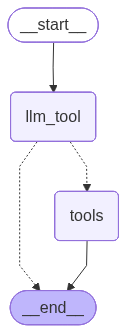

In [119]:
### chatbot node functionality
def llm_tool(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

graph = StateGraph(State)
graph.add_node("llm_tool", llm_tool)
graph.add_node("tools", ToolNode([add_two_numbers]))
graph.add_edge(START, "llm_tool")
graph.add_conditional_edges(
    "llm_tool",
    ### if the latest message from the assistant is a tool call --> tools_condition routs to tools
    ### if the latest message from the assistant is not a tool call --> tool condition routs to end
    tools_condition,
)
graph.add_edge("tools", END)
graph_builder = graph.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [120]:
### Invoking the graph
response = graph_builder.invoke({"messages": "what is 2 plus 2"})

In [121]:
response

{'messages': [HumanMessage(content='what is 2 plus 2', additional_kwargs={}, response_metadata={}, id='9fc3de94-a999-4be2-86a6-24ff47c88c90'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 70, 'total_tokens': 89, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_f8eef93595', 'id': 'chatcmpl-DLYe8X0bUKGxwNB0dqZlhqCc4Cx4o', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d0c74-441e-7c60-bb0e-9ecbaee0d470-0', tool_calls=[{'name': 'add_two_numbers', 'args': {'a': 2, 'b': 2}, 'id': 'call_UuvM0kYZ3xWcGUgnoAIYKanC', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 70, 'output_tokens': 19, '

In [ ]:
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

what is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  add_two_numbers (call_UuvM0kYZ3xWcGUgnoAIYKanC)
 Call ID: call_UuvM0kYZ3xWcGUgnoAIYKanC
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: add_two_numbers

4


In [123]:
### Invoking the graph
response = graph_builder.invoke({"messages": "what is machine learning"})

In [ ]:
for message in response["messages"]:
    message.pretty_print()

================================ Human Message =================================

what is machine learning
================================== Ai Message ==================================

Machine learning is a subset of artificial intelligence (AI) that involves the development of algorithms and statistical models that enable computers to perform tasks without explicit instructions. Instead of being programmed with specific rules, machine learning systems learn from data and improve their performance over time. This is achieved through the use of various techniques, such as supervised learning, unsupervised learning, and reinforcement learning.

Key components of machine learning include:

1. **Data**: The foundation of machine learning, data is used to train models. It can be structured (like databases) or unstructured (like text and images).

2. **Algorithms**: These are the mathematical models that process data and learn patterns. Common algorithms include decision trees, neural ne

In [5]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from pprint import pprint

api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=1000)
api_wrapper_wikipedia = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=1000)

arxiv_tool = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
result = arxiv_tool.invoke("What is the latest research on machine learning?")
pprint(result)

('Published: 2021-01-07\n'
 'Title: DOME: Recommendations for supervised machine learning validation in '
 'biology\n'
 'Authors: Ian Walsh, Dmytro Fishman, Dario Garcia-Gasulla, Tiina Titma, '
 'Gianluca Pollastri, The ELIXIR Machine Learning focus group, Jen Harrow, '
 'Fotis E. Psomopoulos, Silvio C. E. Tosatto\n'
 'Summary: Modern biology frequently relies on machine learning to provide '
 'predictions and improve decision processes. There have been recent calls for '
 'more scrutiny on machine learning performance and possible limitations. Here '
 'we present a set of community-wide recommendations aiming to help establish '
 'standards of supervised machine learning validation in biology. Adopting a '
 'structured methods description for machine learning based on data, '
 'optimization, model, evaluation (DOME) will aim to help both reviewers and '
 'readers to better understand and assess the performance and limitations of a '
 'method or outcome. The recommendations are formula

In [6]:
wikipedia_tool = WikipediaQueryRun(api_wrapper=api_wrapper_wikipedia)
result = wikipedia_tool.invoke("What is the latest research on machine learning?")
pprint(result)

('Page: Neural network (machine learning)\n'
 'Summary: In machine learning, a neural network (NN) or neural net, also '
 'known as an artificial neural network (ANN), is a computational model '
 'inspired by the structure and functions of biological neural networks.\n'
 'A neural network consists of connected units or nodes called artificial '
 'neurons, which loosely model the neurons in the brain. Artificial neuron '
 'models that mimic biological neurons more closely have also been recently '
 'investigated and shown to significantly improve performance. These are '
 'connected by edges, which model the synapses in the brain. Each artificial '
 'neuron receives signals from connected neurons, then processes them and '
 'sends a signal to other connected neurons. The "signal" is a real number, '
 'and the output of each neuron is computed by some non-linear function of the '
 'totality of its inputs, called the activation function. The strength of the '
 'signal at each connection i

In [7]:
#### combine all the tools in the list
tools = [arxiv_tool, wikipedia_tool]

In [10]:
from langchain_openai import ChatOpenAI

llm_model = ChatOpenAI(
    model="gpt-4o",
    temperature=0.0,
    api_key=openai_token,
    base_url=openai_base_url,
)

In [11]:
llm_with_tools = llm_model.bind_tools(tools)

In [ ]:
from langchain_core.messages import HumanMessage

result = llm_with_tools.invoke(
    [HumanMessage(content="What is the latest research on machine learning?")]
)
result.tool_calls

[{'name': 'arxiv',
  'args': {'query': 'latest research on machine learning'},
  'id': 'call_55tEhpDvt83YQPKohTcZRRws',
  'type': 'tool_call'}]

In [16]:
result = llm_with_tools.invoke([HumanMessage(content="india history")])
result.tool_calls

[{'name': 'wikipedia',
  'args': {'query': 'History of India'},
  'id': 'call_jn8BQc3MDkodwH1SFi1uLA2Y',
  'type': 'tool_call'}]

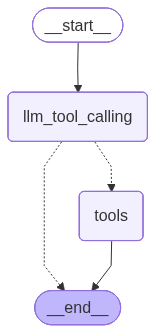

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from pydantic import BaseModel
from typing import Annotated
from IPython.display import Image, display


class MessageState(BaseModel):
    messages: Annotated[list[AnyMessage], add_messages]


def llm_tool_calling(state: MessageState):
    return {"messages": [llm_with_tools.invoke(state.messages)]}


## build the graph
builder = StateGraph(MessageState)
builder.add_node("llm_tool_calling", llm_tool_calling)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "llm_tool_calling")
builder.add_conditional_edges(
    "llm_tool_calling",
    ### if the latest message from the assistant is a tool call --> tools_condition routs to tools
    ### if the latest message from the assistant is not a tool call --> tool condition routs to end
    tools_condition,
)
builder.add_edge("tools", END)


graph_builder = builder.compile()
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [32]:
message = HumanMessage(content="can you teach me programming in python?")
result = graph_builder.invoke({"messages": message})
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

can you teach me programming in python?
================================== Ai Message ==================================

Certainly! I can help you get started with programming in Python. Here's a basic outline of what we'll cover:

1. **Introduction to Python:**
   - What is Python?
   - Installing Python and setting up your environment.

2. **Basic Syntax:**
   - Variables and data types.
   - Basic operations and expressions.

3. **Control Structures:**
   - Conditional statements (`if`, `else`, `elif`).
   - Loops (`for`, `while`).

4. **Functions:**
   - Defining and calling functions.
   - Parameters and return values.

5. **Data Structures:**
   - Lists, tuples, and dictionaries.
   - Basic operations on data structures.

6. **Modules and Libraries:**
   - Importing and using modules.
   - Popular libraries like `math`, `random`, etc.

7. **File Handling:**
   - Reading from and writing to files.



In [33]:
message = HumanMessage(content="summary attention all you need?")
result = graph_builder.invoke({"messages": message})
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

summary attention all you need?
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_dRBcyBhqNsngDPx8I0XOF0Tj)
 Call ID: call_dRBcyBhqNsngDPx8I0XOF0Tj
  Args:
    query: attention all you need
  wikipedia (call_nwlaPCLLn3Zdl0S4rOJi2GyG)
 Call ID: call_nwlaPCLLn3Zdl0S4rOJi2GyG
  Args:
    query: attention all you need
================================= Tool Message =================================
Name: arxiv

Published: 2021-05-06
Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we as

In [34]:
message = HumanMessage(content="give me brief of india history")
result = graph_builder.invoke({"messages": message})
for message in result["messages"]:
    message.pretty_print()

================================ Human Message =================================

give me brief of india history
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_NLVG4PhAzE5KczLtL0keaIyD)
 Call ID: call_NLVG4PhAzE5KczLtL0keaIyD
  Args:
    query: History of India
================================= Tool Message =================================
Name: wikipedia

Page: History of India
Summary: Anatomically modern humans first arrived on the Indian subcontinent between 73,000 and 55,000 years ago. The earliest known human remains in South Asia date to 30,000 years ago. Sedentariness began in South Asia around 7000 BCE; by 4500 BCE, settled life had spread, and gradually evolved into the Indus Valley Civilisation, one of three early cradles of civilisation in the Old World, which flourished between 2500 BCE and 1900 BCE in present-day Pakistan and north-western India. Early in the second millennium BCE, persistent drought caused 

#### ReACT - > General Agent Architecture
- Act : The model calls specific tools
- Observe -> passes the tools output back to the model.
- Reason -> Based on the output response from the tool the model will decided what to do in the next step.


In [36]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper
from pprint import pprint

api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=1000)
api_wrapper_wikipedia = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=1000)
wikipedia_tool = WikipediaQueryRun(api_wrapper=api_wrapper_wikipedia)
arxiv_tool = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)

In [37]:
### custom function
def multiplication(a: int, b: int) -> int:
    """
    multiply two numbers
    args:
        a: int
        b: int
    returns:
        int
    """
    return a * b


def addition(a: int, b: int) -> int:
    """
    add two numbers
    args:
        a: int
        b: int
    returns:
        int
    """
    return a + b


def division(a: int, b: int) -> float:
    """
    divide two numbers
    args:
        a: int
        b: int
    returns:
        float
    """
    return a / b


def subtraction(a: int, b: int) -> int:
    """
    subtract two numbers
    args:
        a: int
        b: int
    returns:
        int
    """
    return a - b


tools = [multiplication, addition, division, subtraction, arxiv_tool, wikipedia_tool]

In [39]:
from langchain_openai import ChatOpenAI

llm_model = ChatOpenAI(
    model="gpt-4o",
    temperature=0.0,
    api_key=openai_token,
    base_url=openai_base_url,
)

In [40]:
llm_with_tools = llm_model.bind_tools(tools)

In [ ]:
result = llm_with_tools.invoke(
    [HumanMessage(content="What is the latest research on machine learning?")]
)
result.tool_calls

[{'name': 'arxiv',
  'args': {'query': 'latest research on machine learning'},
  'id': 'call_ylFKzR2UeDXsRx6dnBXDS1PT',
  'type': 'tool_call'}]

In [42]:
result = llm_with_tools.invoke([HumanMessage(content="what is 2 plus 2")])
result.tool_calls

[{'name': 'addition',
  'args': {'a': 2, 'b': 2},
  'id': 'call_9hbje2DSZvSLw8NBgHv0ACk0',
  'type': 'tool_call'}]

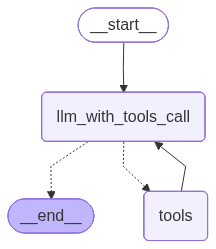

In [55]:
from pydantic import BaseModel
from typing import Annotated
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages


class MessageState(BaseModel):
    messages: Annotated[list[AnyMessage], add_messages]


def llm_tool_calling(state: MessageState):
    return {"messages": [llm_with_tools.invoke(state.messages)]}


from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory_saver = MemorySaver()
builder = StateGraph(MessageState)
builder.add_node("llm_with_tools_call", llm_tool_calling)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "llm_with_tools_call")
builder.add_conditional_edges(
    "llm_with_tools_call",
    ### if the latest message from the assistant is a tool call --> tools_condition routs to tools
    ### if the latest message from the assistant is not a tool call --> tool condition routs to end
    tools_condition,
)
builder.add_edge("tools", "llm_with_tools_call")
graph_builder = builder.compile(checkpointer=memory_saver)
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [57]:
config = {"configurable": {"thread_id": "1"}}
message = graph_builder.invoke({"messages": "what is 2 plus 2"}, config=config)
for message in message["messages"]:
    message.pretty_print()

================================ Human Message =================================

what is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  addition (call_Phxb5umsZDfAY6vurypm9y6q)
 Call ID: call_Phxb5umsZDfAY6vurypm9y6q
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: addition

4
================================== Ai Message ==================================

2 plus 2 equals 4.


In [58]:
config = {"configurable": {"thread_id": "1"}}
message = graph_builder.invoke({"messages": "multiply that number by 3"}, config=config)
for message in message["messages"]:
    message.pretty_print()

================================ Human Message =================================

what is 2 plus 2
================================== Ai Message ==================================
Tool Calls:
  addition (call_Phxb5umsZDfAY6vurypm9y6q)
 Call ID: call_Phxb5umsZDfAY6vurypm9y6q
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: addition

4
================================== Ai Message ==================================

2 plus 2 equals 4.
================================ Human Message =================================

multiply that number by 3
================================== Ai Message ==================================
Tool Calls:
  multiplication (call_NojuGHryTE4D6HQMF8R7tnoX)
 Call ID: call_NojuGHryTE4D6HQMF8R7tnoX
  Args:
    a: 4
    b: 3
================================= Tool Message =================================
Name: multiplication

12
================================== Ai Message ===============================

In [ ]:
message = graph_builder.invoke(
    {
        "messages": "what is 2 plus 2 then what ever result that you get multiply it by 3 then divide by 2 "
    }
)
for message in message["messages"]:
    message.pretty_print()

================================ Human Message =================================

what is 2 plus 2 then what ever result that you get multiply it by 3 then divide by 2 
================================== Ai Message ==================================
Tool Calls:
  addition (call_gJS7SULx1H78aLCl9sCL1ise)
 Call ID: call_gJS7SULx1H78aLCl9sCL1ise
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: addition

4
================================== Ai Message ==================================
Tool Calls:
  multiplication (call_AKmz83Jik5x3Lpl5DBMCCE24)
 Call ID: call_AKmz83Jik5x3Lpl5DBMCCE24
  Args:
    a: 4
    b: 3
================================= Tool Message =================================
Name: multiplication

12
================================== Ai Message ==================================
Tool Calls:
  division (call_1FMzSkMhH6IAFsnVEUuSW0oD)
 Call ID: call_1FMzSkMhH6IAFsnVEUuSW0oD
  Args:
    a: 12
    b: 2
=============